### Титаник: определяем шанс выживания
1. EDA - анализ данных, ищем главные признаки

In [ ]:
import pandas as pd

# Скачиваем открытый датасет "Титаник"
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# выяснили что Sex сильно влияет на survived
print(df.groupby('Sex')['Survived'].mean())

2. Preparation - подготавливаем данные, очищаем

**Важная деталь:** Деревьям решений и Случайному лесу избыточные столбцы не вредят, но `drop_first=True` — это хорошая привычка, которая экономит память и бережет линейные алгоритмы от ошибок.

In [ ]:
import pandas as pd

# 1. Заполняем пропуски
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Отбираем нужные колонки (убираем имя, номер билета и каюту - они слишком уникальны)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# 3. Переводим текст в числа через One-Hot Encoding
# drop_first=True убирает избыточный столбец (например, оставляет только 'Sex_male', так как 0 автоматически значит female)
# Embarked_C - убираем, так как известно что он 1, если Embarked_Q=0 и Embarked_S=0 
X = pd.get_dummies(df[features], columns=['Sex', 'Embarked'], drop_first=True, dtype=int)
y = df['Survived']

print("--- Готовая матрица X (первые 3 строки) ---")
print(X.head(3))
print(y.head(3))

## Шаг 3: Обучение модели и оценка через ROC-AUC

- Теперь у нас есть полностью подготовленная матрица $X$ и целевая переменная $y$. 
- Обучим **Random Forest** (Случайный лес) и измерим его ROC-AUC на тестовой выборке

#### 1. Узнаем лучшие настройки для **Random Forest** и нашего датасета
- пробуем GridSearchCV (Полный перебор) - он перебирает все возможные комбинации параметров и проверяет их качество через кросс-валидацию
- Минус: Если параметров много, перебор займет вечность. Он тратит кучу времени на заведомо плохие комбинации.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Создаем базовую модель
rf = RandomForestClassifier(random_state=42)

# 2. Передаем конкретные диапазоны для проверки
param_grid = {
    'n_estimators': [50, 100, 200],          # Сколько деревьев в лесу
    'max_depth': [6, 8, 10, 12],                 # Глубина вокруг нашей лучшей (8)
    'min_samples_split': [2, 5, 10],             # Сколько объектов нужно для деления узла
    'min_samples_leaf': [1, 2, 4]             # Минимальное число пассажиров в листе
}

# 3. Настраиваем поиск (n_jobs=-1 ускоряет процесс, используя все ядра процессора)
grid_search_advanced = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

# 4. Запускаем обучение
grid_search_advanced.fit(X, y)

# 5. Выводим новые лучшие результаты
print("--- Лучшие параметры ---")
for param, value in grid_search_advanced.best_params_.items():
    print(f"{param}: {value}")

print(f"\nНовая точность (Accuracy) на кросс-валидации: {grid_search_advanced.best_score_:.4f}")



- используем **Optuna** (Байесовская оптимизация) - работает на основе вероятностных моделей. Optuna запускает несколько случайных комбинаций, смотрит на результаты и понимает, в какой стороне параметры улучшают метрику, а в какой ухудшают
- Плюс: Находит лучшие параметры в 5–10 раз быстрее, чем GridSearchCV, так как не тратит время на пустые вычисления.

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Отключаем лишние логи Optuna, оставляем только важные сообщения
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Создаем функцию-цель (objective)
def objective(trial):
    # Задаем диапазоны поиска (аналог param_grid)
    # suggest_int ищет целые числа, suggest_categorical — выбирает из списка
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250, step=50),
        'max_depth': trial.suggest_int('max_depth', 6, 14),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'random_state': 42,
        'n_jobs': -1 # Ускоряет обучение отдельных моделей
    }
    
    # Создаем модель с предложенными параметрами
    rf = RandomForestClassifier(**params)
    
    # Считаем качество на кросс-валидации (cv=5, метрика roc_auc)
    # Мы берем среднее значение по 5 фолдам
    scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    
    # Возвращаем среднюю метрику — её Optuna будет максимизировать
    return scores.mean()

# 2. Создаем исследование (Study)
# direction='maximize' означает, что мы ищем МАКСИМУМ метрики ROC-AUC
study = optuna.create_study(direction='maximize')

# 3. Запускаем оптимизацию
# n_trials=30 означает, что алгоритм проверит всего 30 комбинаций (вместо 108 в GridSearchCV)
print("Запуск оптимизации параметров...")
study.optimize(objective, n_trials=30, show_progress_bar=True)

# 4. Выводим результаты
print("\n--- Лучшие параметры ---")
for param, value in study.best_params.items():
    print(f"{param}: {value}")

print(f"\nНовая точность (ROC-AUC) на кросс-валидации: {study.best_value:.4f}")


#### 2. Подставим полученные настройки в обучение

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Делим данные на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# аргументы - Гиперпараметры
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, min_samples_leaf=4, min_samples_split=2)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Качество модели (ROC-AUC): {auc:.3f}") 
# Качество модели с GridSearchCV (ROC-AUC): 0.913
# Качество модели с Optuna (ROC-AUC): 0.897

#### Финальный честный батл GridSearchCV и Optuna

In [ ]:
# Модель 1: Ваши параметры, которые дали лучший скор в GridSearchCV
model_grid = RandomForestClassifier(
    n_estimators=50, max_depth=10, min_samples_leaf=4, min_samples_split=2, random_state=42, n_jobs=-1
)
model_grid.fit(X_train, y_train)
auc_grid = roc_auc_score(y_test, model_grid.predict_proba(X_test)[:, 1])

# Модель 2: Параметры, которые нашла Optuna
model_optuna = RandomForestClassifier(
    n_estimators=150, max_depth=11, min_samples_leaf=3, min_samples_split=8, random_state=42, n_jobs=-1
)
model_optuna.fit(X_train, y_train)
auc_optuna = roc_auc_score(y_test, model_optuna.predict_proba(X_test)[:, 1])

print(f"Финальный честный ROC-AUC на X_test:")
print(f"Пакет параметров Grid:   {auc_grid:.4f}")
print(f"Пакет параметров Optuna: {auc_optuna:.4f}")


Победитель для продакшена — Пакет Grid.Модель с 50 деревьями будет обучаться и предсказывать в 3 раза быстрее, а в оперативной памяти займет в 3 раза меньше места, выдавая при этом точно такую же точность, как тяжелая модель от Optuna.

### 3. Улучшим качество модели через Feature Engineering (конструирование признаков)
- процесс, когда мы с помощью здравого смысла и знания предметной области извлекаем из исходных данных «скрытые» сигналы.
- cырая колонка `Name` (Имя) кажется бесполезной для модели, 
а `Fare` (Цена билета) может вводить в заблуждение, если билет покупался на целую семью. 
Давайте превратим эти данные в мощные фичи!

Cупер-фичи для «Титаника»

1. **Титул из имени (`Title`):** В именах зашифрованы обращения (`Mr.`, `Mrs.`, `Miss.`, `Master.`)
    
2. **Размер семьи (`FamilySize`):** `SibSp` (братья/сестры/супруги) + `Parch` (родители/дети) + 1 (сам пассажир). Маленькие семьи (2–4 человека) сплоченно пробирались к лодкам
    
3. **Флаг одиночки (`IsAlone`):** Простой бинарный признак (1 — если ехал один, 0 — если с кем-то).
    
4. **Умная индивидуальная цена (`FarePerPerson`):** В билетах Титаника указана _суммарная_ цена на всю группу. Если семья из 5 человек купила билет за £50, реальная стоимость места — £10 (3-й класс). Без деления на размер семьи модель подумает, что это богачи из 1-го класса.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Загружаем данные
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# === FEATURE ENGINEERING ===

# 1. Извлекаем обращение (Title) из колонки Name
# Текст вида "Braund, Mr. Owen Harris" -> извлекаем "Mr"
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Объединяем редкие обращения (докторов, священников, графов) в категорию 'Rare'
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# 2. Семья и Одиночки
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3. Индивидуальная цена билета
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 4. УМНОЕ заполнение возраста:
# Заполняем пропущенный возраст медианой ВНУТРИ его титула!
# (У Master медианный возраст около 4 лет, а у Mr — около 30 лет)
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Заполняем порт
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# === ПОДГОТОВКА И ОБУЧЕНИЕ ===

features = ['Pclass', 'Title', 'Age', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Embarked']

# Кодируем категориальные переменные (Title, Embarked)
X = pd.get_dummies(df[features], columns=['Title', 'Embarked'], drop_first=True, dtype=int)
y = df['Survived']

# Разбиваем и обучаем тот же Random Forest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, min_samples_leaf=4, min_samples_split=2)
model.fit(X_train, y_train)

# Оценка
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Новый ROC-AUC после Feature Engineering: {auc:.3f}") 
# Новый ROC-AUC после Feature Engineering с GridSearchCV: 0.913
# Новый ROC-AUC после Feature Engineering с Optuna: 0.913

Новый ROC-AUC после Feature Engineering: 0.913


### Матрица ошибок
- в каких ситуациях модель ошибается чаще: когда «хоронит» выживших или когда считает погибших спасенными

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Делаем предсказания
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Отрисовка матрицы с правильным контекстом
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Погиб (0)', 'Выжил (1)'])
disp.plot(cmap=plt.cm.Oranges, values_format='d') # Сменим цвет на оранжевый для разнообразия

plt.title('Матрица ошибок на Титанике', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Предсказание модели')
plt.ylabel('Реальный исход')
plt.show()


### Важность признаков (Feature Importance)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Собираем важность признаков в DataFrame
importances = model.feature_importances_
feature_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

# Строим график
plt.figure(figsize=(10, 6))
feature_imp.plot(kind='barh', color='teal')
plt.title('Что больше всего повлияло на выживание пассажира?', fontsize=14, fontweight='bold')
plt.xlabel('Относительная важность')
plt.tight_layout()
plt.show()


#### SHAP

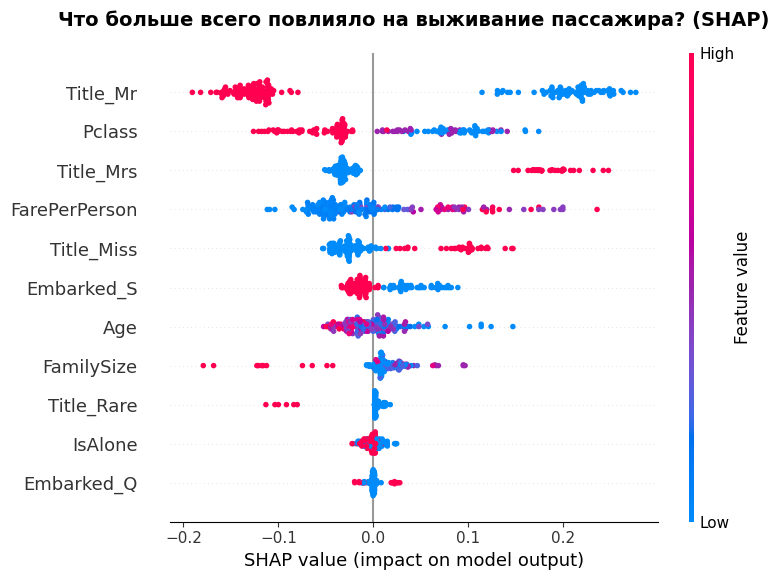

In [4]:
import shap
import matplotlib.pyplot as plt

# 1. Создаем объясняющий алгоритм для Random Forest
explainer = shap.TreeExplainer(model)

# 2. Считаем SHAP-значения на тестовой выборке
shap_values_all = explainer(X_test)

# 3. Извлекаем значения для Класса 1 (Выжил)
# Это нужно, чтобы цвета точек показывали влияние именно на спасение пассажира
shap_values_survived = shap_values_all[..., 1]

# 4. Строим график "Пчелиный рой"
plt.figure(figsize=(10, 6))
plt.title('Что больше всего повлияло на выживание пассажира? (SHAP)', fontsize=14, fontweight='bold', pad=20)

shap.summary_plot(shap_values_survived, X_test, show=False)

plt.tight_layout()
plt.show()


## 4. Пробуем CatBoost

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, verbose=0, random_state=42)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]
score = roc_auc_score(y_test, preds)
print(f"CatBoost: ROC-AUC = {score:.4f}")

## 5. Пробуем Стэкинг

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Определяем базовые модели, которые мы уже настроили
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_leaf=4, min_samples_split=2, random_state=42, n_jobs=-1)),
    ('catboost', CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, verbose=0, random_state=42))
]

# 2. Создаем стекинг. В качестве финального судьи (meta-learner) берем простую логистическую регрессию
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# 3. Обучаем финальный ансамбль
stacking_model.fit(X_train, y_train)

# 4. Проверяем честный ROC-AUC
stacking_preds = stacking_model.predict_proba(X_test)[:, 1]
stacking_score = roc_auc_score(y_test, stacking_preds)

print(f"Финальный баттл:")
print(f"Random Forest (Grid): {auc_grid:.4f}")
print(f"CatBoost:             {score:.4f}")
print(f"Стекинг (Ансамбль):   {stacking_score:.4f}")


### Стекинг показал лучшее качество по ROC-AUC!

Главный минус стекинга в продакшене: Цена «золотой медали»

В соревнованиях по Data Science (вроде Kaggle) стекинг — это стандарт. Но бизнес его не любит по трем главным причинам:

- **Инженерный ад и поддержка:** Чтобы стекинг работал в продакшене, вам нужно развернуть, поддерживать и мониторить **все** базовые модели плюс мета-модель. Если одна из моделей (например, тяжелый CatBoost) начнет сбоить или упадет по памяти, упадет вся система.
- **Высокий SLA (Задержка/Latency):** Представьте систему транзакций по банковским картам. Решение о блокировке из-за фрода нужно принять за **10–50 миллисекунд**. В стекинге данные должны последовательно пройти через Random Forest, CatBoost, а потом через логистическую регрессию. Время ответа критически растет.
- **Неинтерпретируемость:** Бизнесу (и регуляторам) нужно понимать, _почему_ клиенту отказали в кредите. В CatBoost это понять можно. В стекинге, где мета-модель принимает решение на основе абстрактных вероятностей других моделей, объяснить логику человеку становится практически невозможно.

---